# Day 5 — Advancing the Core Model & Sprint Review

## 1. Core Architecture Selection

The project uses **tabular data** to predict the continuous `Selling_Price` target.

Therefore, a **Dense Neural Network** is selected as the core deep learning architecture because it is suitable for tabular regression problems.

The Sprint 1 Neural Network achieved:

- **MAE:** 120,246.71
- **RMSE:** 209,799.39
- **R²:** 0.7380

The goal of Sprint 2 is to further tune and improve this core model and achieve better performance than the Sprint 1 model.

## 2. Sprint 2 Experiment Log

The Sprint 2 experiments will focus on improving the Sprint 1 Dense Neural Network.

For each experiment, the following will be recorded:

- Model architecture
- Learning rate
- Batch size
- Number of epochs
- Regularization / Dropout
- Validation performance
- Test performance

The goal is to identify a configuration that improves upon the Sprint 1 model.

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [7]:
df = pd.read_csv('/content/kc_house_data.csv')

In [8]:
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [9]:
df.drop(columns=['id','date'], inplace=True)

In [10]:
numeric_cols = df.select_dtypes(include='number').columns


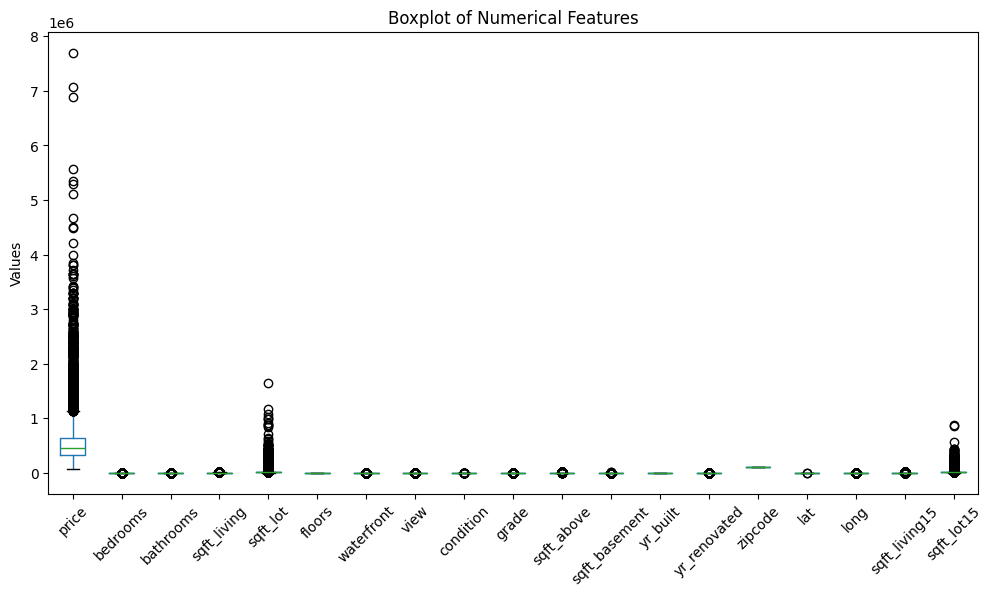

In [11]:
# Select numerical columns


plt.figure(figsize=(12, 6))

df[numeric_cols].boxplot()

plt.title("Boxplot of Numerical Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.grid(False)

plt.show()

In [12]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## Exploratory Data Analysis: Numerical Features

The dataset contains **21,613 observations and 21 columns**. The numerical features were examined using descriptive statistics and boxplots to understand their distributions and identify potential outliers.

### Descriptive Statistics

The target variable, `price`, has a mean of approximately **$540,088** and a median of **$450,000**. The difference between the mean and median suggests that the price distribution is right-skewed.

The main property features show the following patterns:

- `bedrooms` has a mean of **3.37**, with values ranging from 0 to 33.
- `bathrooms` has a mean of **2.11**, ranging from 0 to 8.
- `sqft_living` has a mean of approximately **2,080 sq ft**, with a maximum of 13,540 sq ft.
- `sqft_lot` is highly variable, with a mean of approximately **15,107 sq ft** and a maximum of **1,651,359 sq ft**.
- `yr_built` ranges from **1900 to 2015**, while `yr_renovated` contains many zero values, indicating properties that were not renovated.
- `sqft_living15` and `sqft_lot15` also show substantial variation.

### Outlier Analysis

The boxplot shows several potential outliers, particularly in:

- `price`
- `sqft_living`
- `sqft_lot`
- `sqft_living15`
- `sqft_lot15`

These observations are not automatically removed because they may represent genuine large or expensive properties rather than errors.

The large differences in scale between features also show why **feature scaling will be important before training the neural network**.

Overall, the dataset contains sufficient observations and useful numerical features for building a regression model to predict house prices.

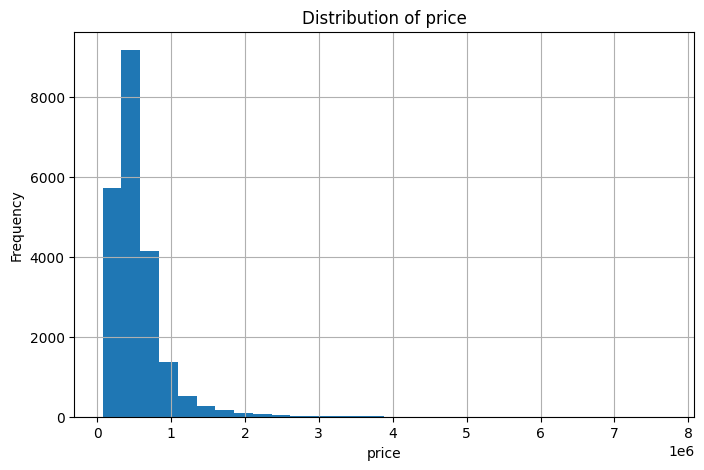

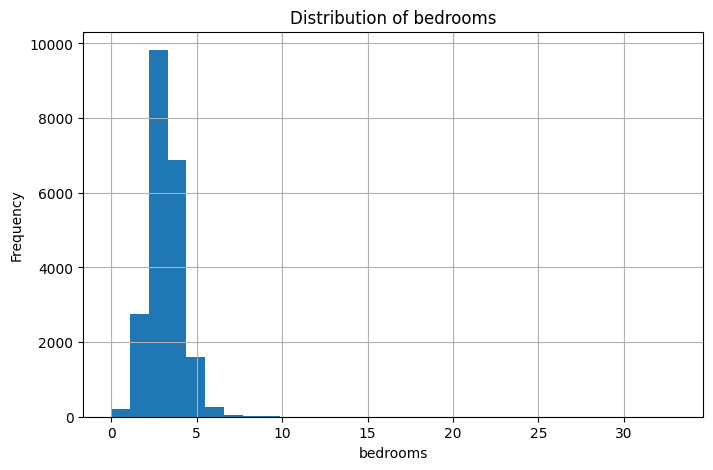

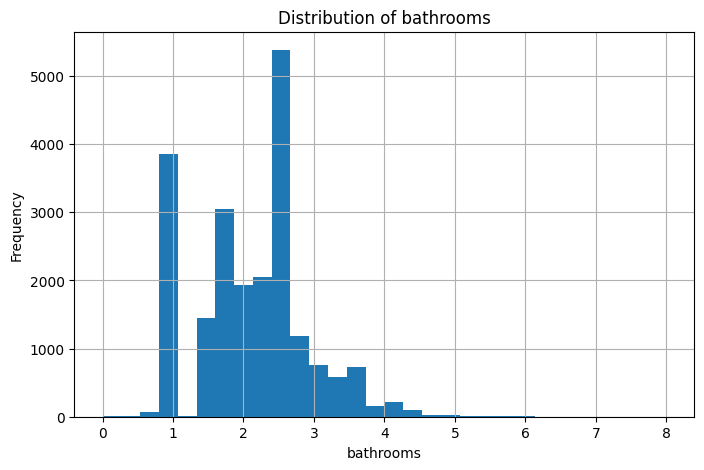

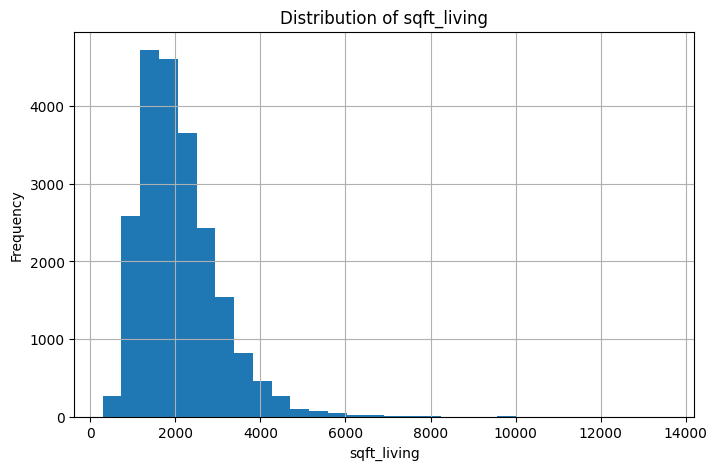

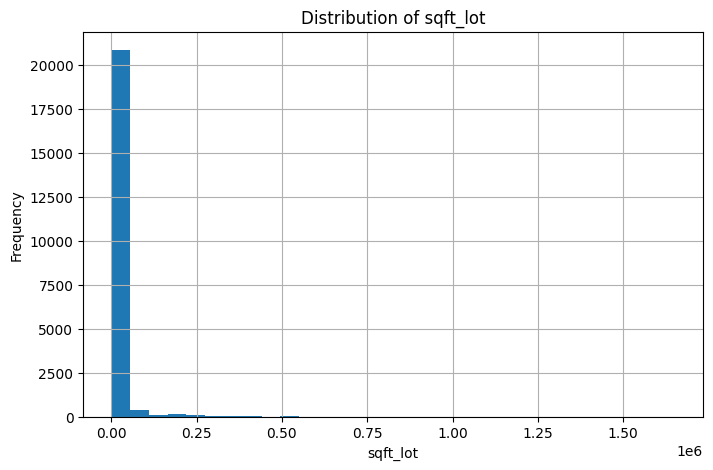

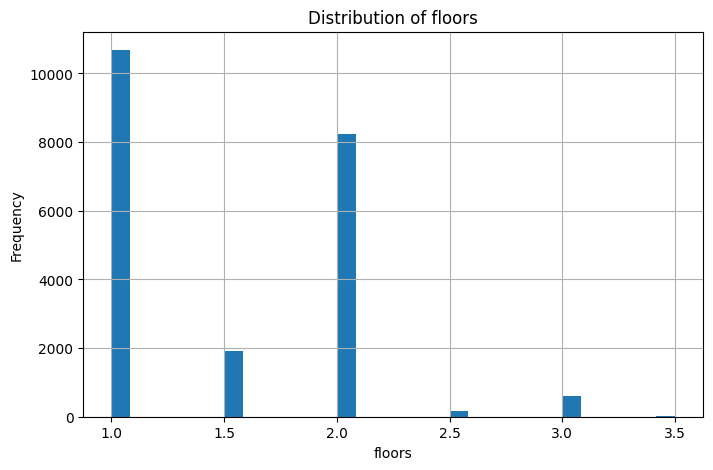

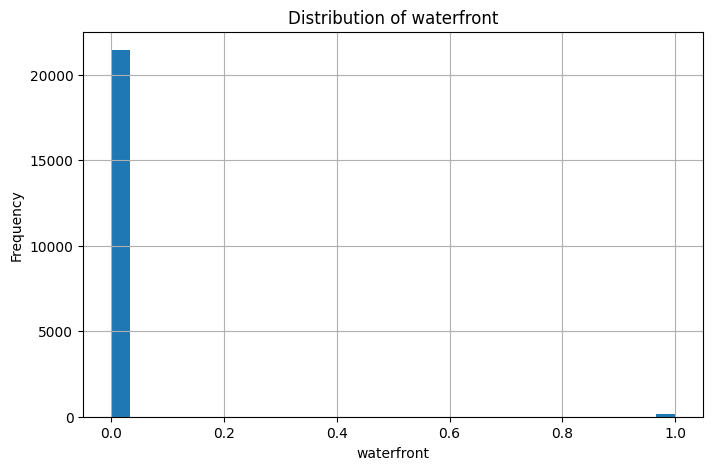

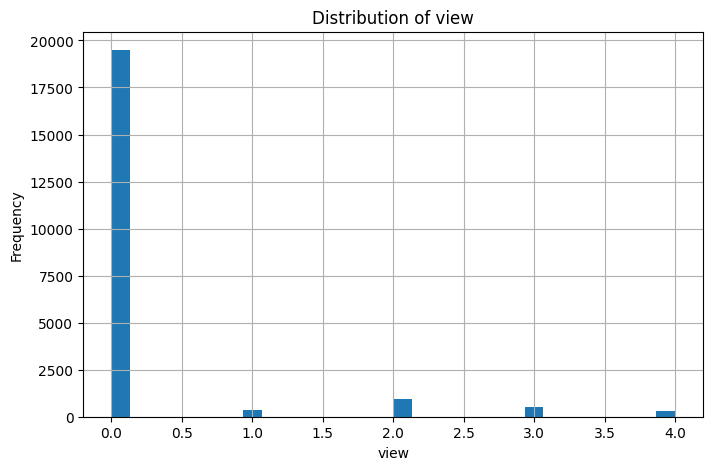

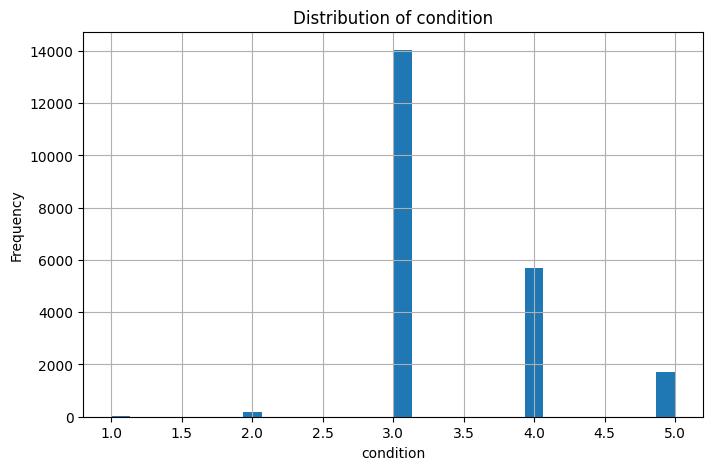

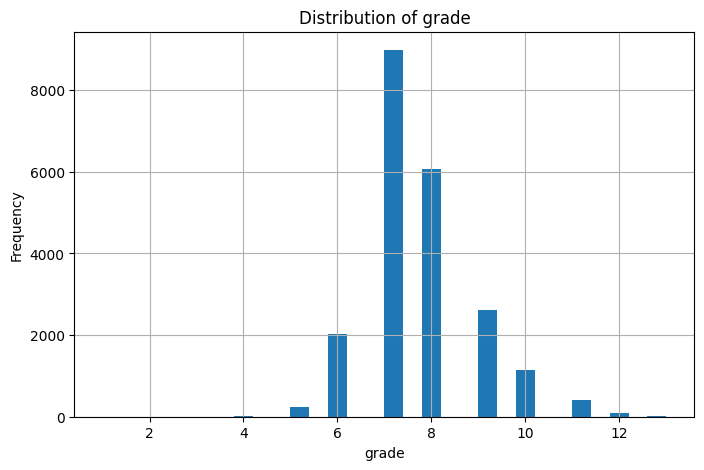

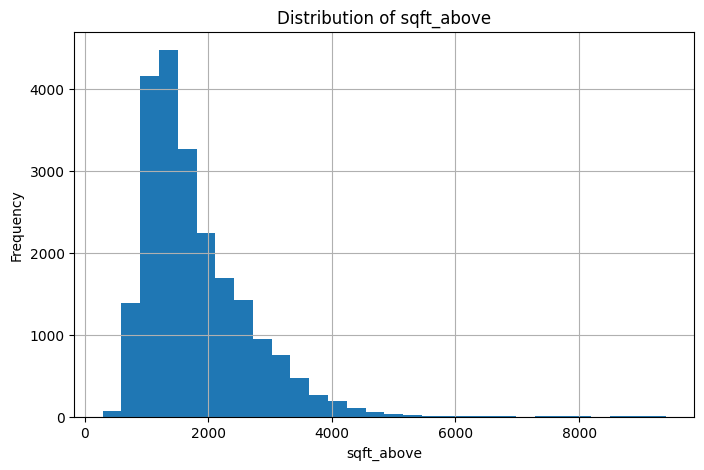

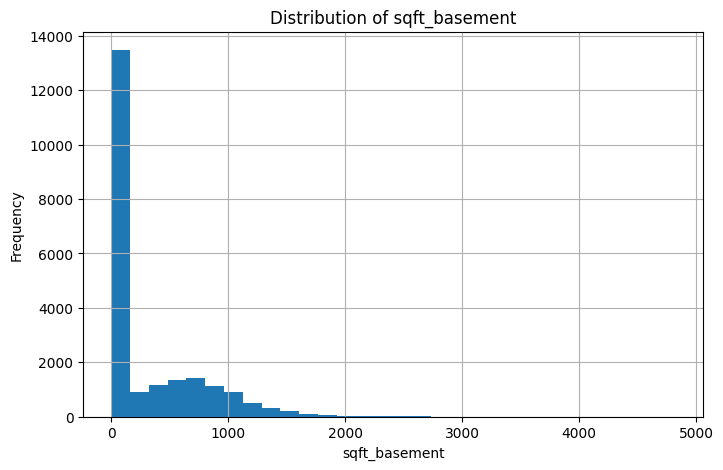

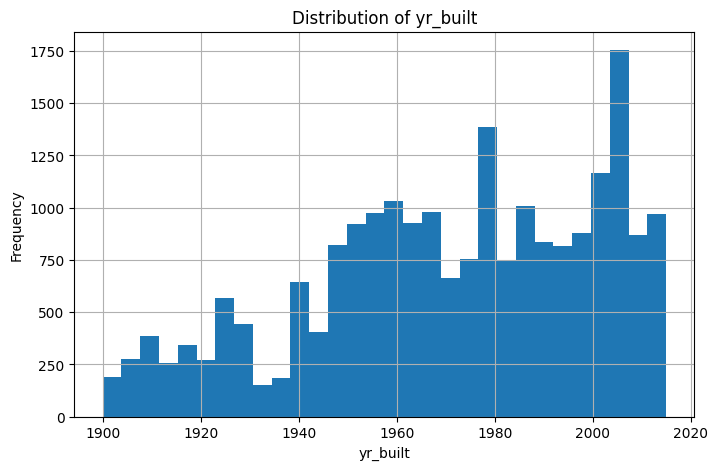

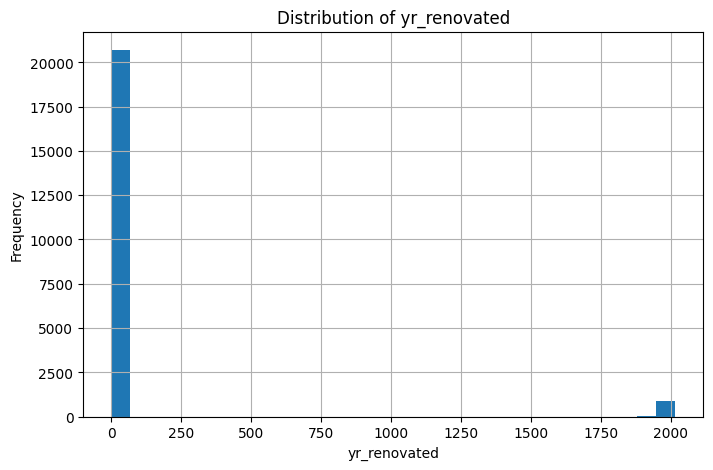

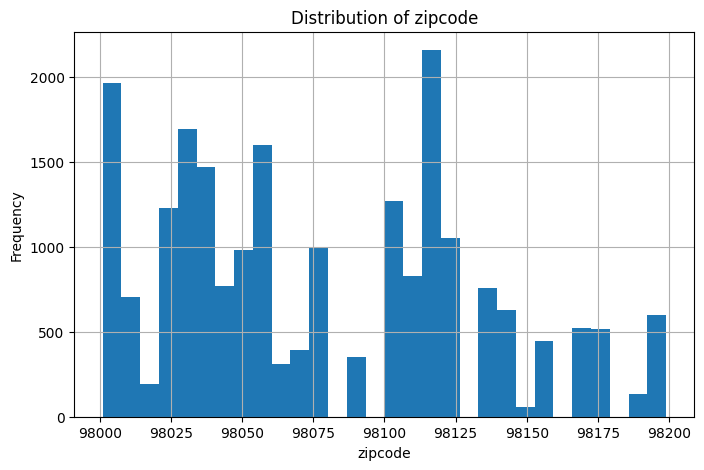

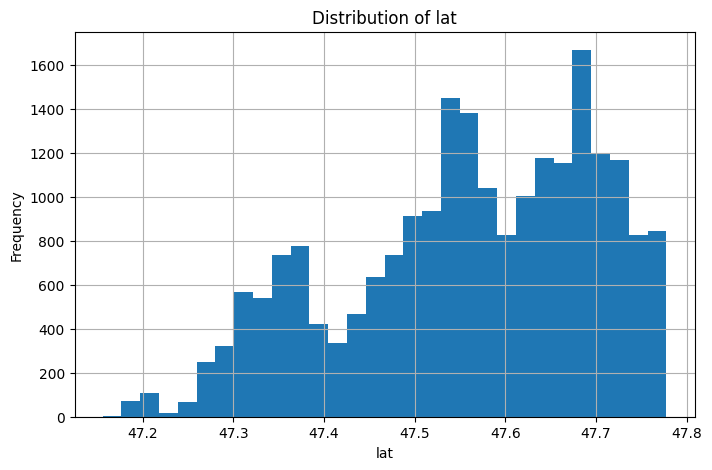

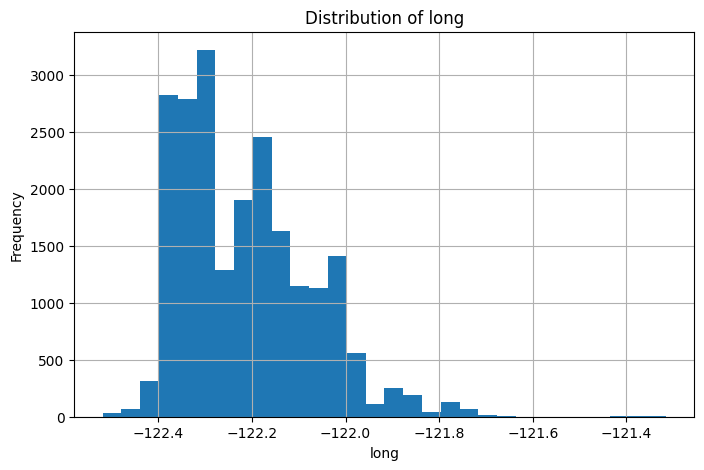

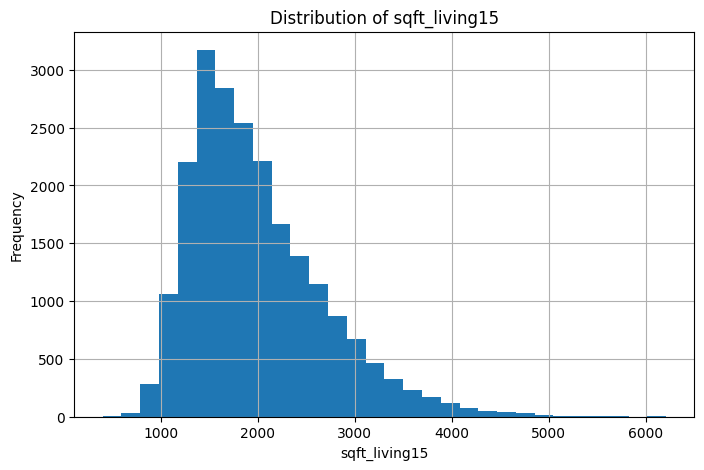

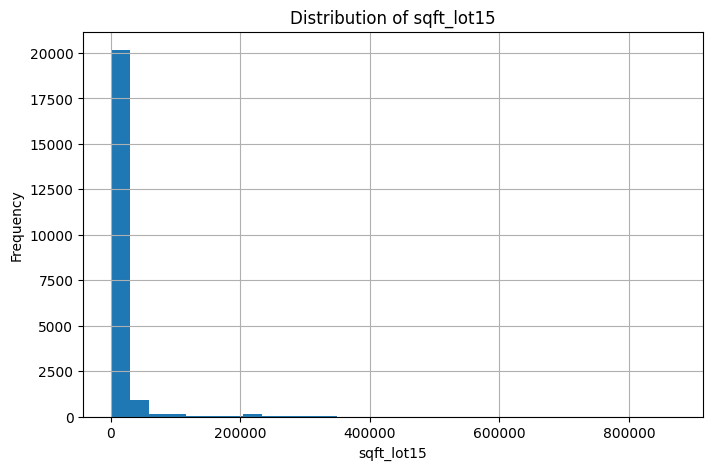

In [13]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col], bins=30)

    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.grid(True)
    plt.show()

In [14]:
df.isnull().sum()

,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0
grade,0


## Sprint 1 Planning

### Sprint Goal

The main goal of Sprint 1 is to understand the car price dataset, complete the initial data preprocessing, and establish a baseline regression model that can be used for comparison with the neural network.

### Initial Backlog Tasks

1. **Dataset Selection and Understanding**
   - Load and inspect the car price dataset.
   - Identify numerical and categorical features.
   - Check for missing values and potential outliers.

2. **Data Preprocessing**
   - Handle missing values.
   - Encode categorical features.
   - Scale numerical features.
   - Split the data into training, validation, and test sets.

3. **Baseline Model**
   - Build a simple regression baseline using `DummyRegressor`.
   - Evaluate it using MAE, RMSE, and R².
   - Record the baseline results.

4. **Neural Network Baseline**
   - Build a Keras neural network for regression.
   - Train it using the training and validation sets.
   - Compare its performance with the baseline model.

### Acceptance Criteria

- The dataset is loaded and inspected successfully.
- Preprocessing is completed without data leakage.
- A baseline regression model is trained and evaluated.
- MAE, RMSE, and R² are recorded.
- The neural network can be trained and evaluated.
- All results are documented in the notebook.

In [15]:
# Drop ID, date, and target
X = df.drop(columns=['price'])
y = df['price']

# Numerical columns
numeric_cols = X.columns.tolist()

# Numerical pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols)
])

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Train shape:", X_train_processed.shape)
print("Validation shape:", X_val_processed.shape)
print("Test shape:", X_test_processed.shape)

Train shape: (12967, 18)
Validation shape: (4323, 18)
Test shape: (4323, 18)


### Baseline: LinearRegression

In [16]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline model
baseline = DummyRegressor(strategy="mean")

# Train baseline
baseline.fit(X_train_processed, y_train)

# Predictions
baseline_pred = baseline.predict(X_test_processed)

# Evaluation
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Results")
print("----------------")
print(f"MAE:  {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R²:   {baseline_r2:.4f}")

Baseline Results
----------------
MAE:  242663.5953
RMSE: 410080.4851
R²:   -0.0009


### Baseline Results

A `DummyRegressor` using the mean strategy was used as the baseline model.

The baseline achieved an MAE of **242,663.5953**, an RMSE of **410,080.4851**, and an R² score of **-0.0009**.

The baseline predicts the mean `price` for every observation, so it provides a simple reference point rather than a meaningful predictive model.

The neural network will be compared against this baseline. A successful neural network should achieve lower MAE and RMSE and a higher R² score.

The negative R² score indicates that the baseline performs slightly worse than simply using the mean as a reference, which is expected for a `DummyRegressor`.

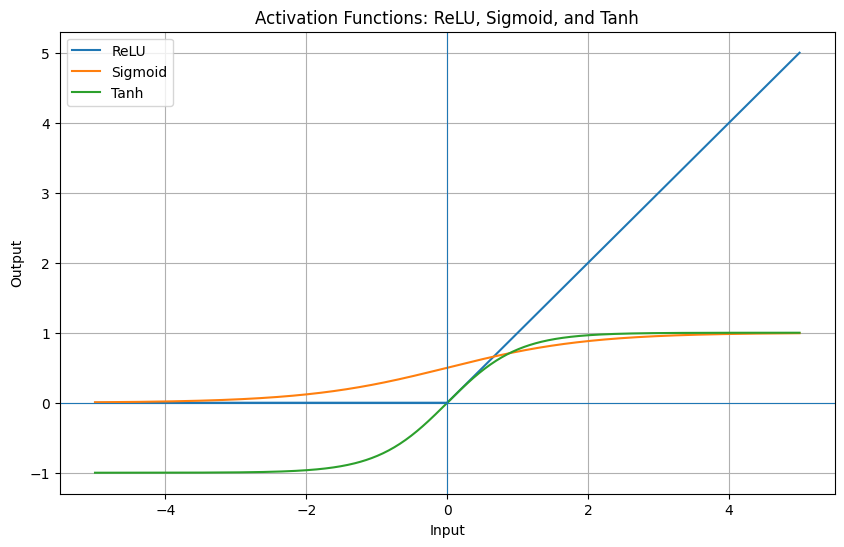

In [17]:
# Range of inputs
x = np.linspace(-5, 5, 500)

# Activation functions
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(x, relu, label='ReLU')
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, tanh, label='Tanh')

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Activation Functions: ReLU, Sigmoid, and Tanh')
plt.legend()
plt.grid(True)

plt.show()

### Activation Functions

The plot compares three commonly used activation functions: ReLU, Sigmoid, and Tanh.

- **ReLU:** Outputs 0 for negative inputs and keeps positive inputs unchanged. It is commonly used in hidden layers of neural networks.
- **Sigmoid:** Converts inputs into values between 0 and 1, making it suitable for binary classification output layers.
- **Tanh:** Converts inputs into values between -1 and 1 and is centered around zero.

For this project, **ReLU** is used in the hidden layers, while the final output layer for the regression task uses **no activation function** (`Dense(1)`).

### Output Activation and Loss Function

Since the Phase 3 project is a **regression task** where the goal is to predict a continuous house price, the output layer should use **no activation function**.

The final layer is:

`Dense(1)`

The single neuron produces a continuous numerical value representing the predicted house price. No activation is used because the model needs to be able to predict values across the full range of possible prices.

For the loss function, **Mean Squared Error (MSE)** is appropriate:

`loss="mse"`

MSE measures the average squared difference between the actual and predicted prices. Squaring the errors gives larger errors more weight, which encourages the neural network to reduce large prediction errors.

Therefore, the configuration is:

- **Task:** Regression
- **Output layer:** `Dense(1)`
- **Output activation:** None (linear)
- **Loss function:** Mean Squared Error (MSE)

This differs from binary classification, where a sigmoid activation and binary cross-entropy would be used. Since the target here is a continuous `price`, a linear output with MSE is the appropriate choice.

In [18]:
# Sample input
x = np.array([[2.0, 3.0]])

# Layer 1 weights and bias
W1 = np.array([
    [0.5, 0.2, 0.1],
    [0.4, 0.3, 0.6]
])

b1 = np.array([[0.1, 0.2, 0.3]])

# Layer 2 weights and bias
W2 = np.array([
    [0.7],
    [0.5],
    [0.2]
])

b2 = np.array([[0.1]])

# Forward pass - Layer 1
z1 = x @ W1 + b1
a1 = np.maximum(0, z1)  # ReLU

# Forward pass - Layer 2
z2 = a1 @ W2 + b2

# Final output
y_pred = z2

print("Layer 1 pre-activation:", z1)
print("Layer 1 activation:", a1)
print("Final output:", y_pred)

Layer 1 pre-activation: [[2.3 1.5 2.3]]
Layer 1 activation: [[2.3 1.5 2.3]]
Final output: [[2.92]]


### NumPy Forward Pass

A forward pass calculates the output of a neural network from an input without using a deep-learning framework.

The sample input is passed through two layers.

First, the weighted sum is calculated:

`z1 = x @ W1 + b1`

The ReLU activation is then applied:

`a1 = ReLU(z1)`

The activated values are passed to the second layer:

`z2 = a1 @ W2 + b2`

Since this example represents a regression network, the final output uses a **linear activation**, so the prediction is simply:

`y_pred = z2`

This demonstrates the basic process used by neural networks: **input → weighted sum → activation → next layer → prediction**.

### Four-Step Training Loop

**1. Forward Pass**  
Input → Neural Network → Prediction

⬇️

**2. Calculate Loss**  
Prediction ↔ Actual Value → Loss

⬇️

**3. Backpropagation**  
Loss → Calculate Gradients

⬇️

**4. Update Weights**  
Gradients + Adam → Updated Weights

⬇️

**Repeat for the next batch and epoch**

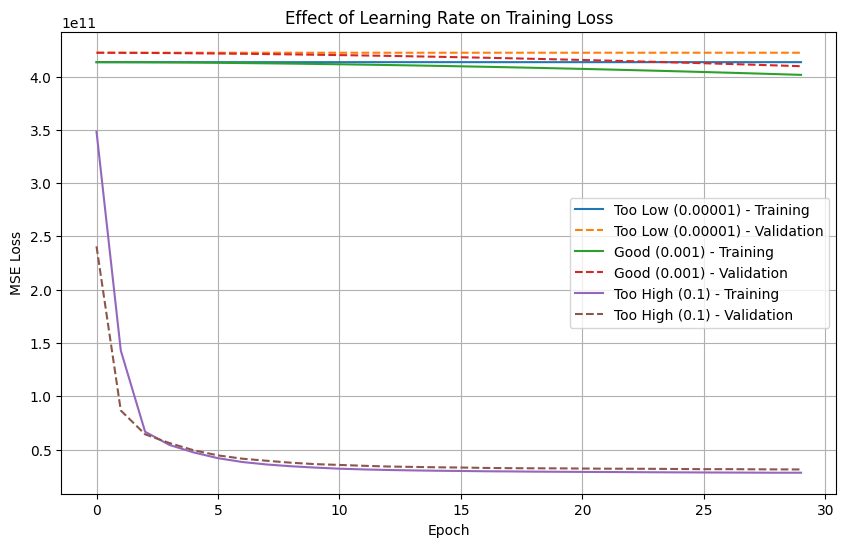

In [19]:
import tensorflow as tf

learning_rates = {
    "Too Low (0.00001)": 0.00001,
    "Good (0.001)": 0.001,
    "Too High (0.1)": 0.1
}

histories = {}

for name, lr in learning_rates.items():

    # Small network
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_processed.shape[1],)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

    # Compile with different learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="mse"
    )

    # Train
    history = model.fit(
        X_train_processed,
        y_train,
        validation_data=(X_val_processed, y_val),
        epochs=30,
        batch_size=32,
        verbose=0
    )

    histories[name] = history


# Plot loss curves
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["loss"],
        label=f"{name} - Training"
    )
    plt.plot(
        history.history["val_loss"],
        linestyle="--",
        label=f"{name} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Effect of Learning Rate on Training Loss")
plt.legend()
plt.grid(True)
plt.show()

### Learning Rate Experiment

A small neural network was trained using three different learning rates while keeping the architecture, batch size, number of epochs, and data split fixed.

- **0.00001 (Too Low):** The loss decreases very slowly, indicating that the weight updates are too small for efficient learning.
- **0.001 (Good):** The loss decreases steadily and provides a good balance between learning speed and stability.
- **0.1 (High):** The loss decreases very quickly during the first few epochs and then levels off. In this experiment, it did not show severe instability, but the learning rate is relatively large and may be less reliable with different data or initializations.

Overall, the experiment shows that the learning rate strongly affects how quickly the neural network converges. The learning rate of **0.001** provides a stable learning behavior and is a reasonable choice for this project.

### Backpropagation and the Chain Rule

Backpropagation is the process used by a neural network to determine how much each weight and bias contributed to the prediction error.

After the forward pass, the model calculates the loss by comparing its prediction with the actual target. Backpropagation then works backward through the network and computes the **gradient of the loss with respect to each parameter**. These gradients tell the optimizer how the weights should be adjusted to reduce the loss.

The **chain rule** is involved because the output of one layer becomes the input to the next layer. Therefore, the loss depends on earlier weights indirectly through several intermediate calculations.

For example:

`Weight → Hidden Layer → Output → Loss`

To find how a weight affects the loss, the chain rule combines the derivatives through each step:

`dLoss/dWeight = dLoss/dOutput × dOutput/dHidden × dHidden/dWeight`

This allows the network to efficiently calculate gradients for all its parameters, which are then used by the optimizer, such as Adam, to update the weights.

In simple terms, **backpropagation works backward from the error to determine how each parameter should change, while the chain rule makes it possible to calculate these effects through multiple connected layers.**

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Number of input features
n_features = X_train_processed.shape[1]

# Build Sequential neural network
model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)  # Linear output for regression
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

### Neural Network Architecture

The Phase 3 project is a **regression task** that predicts a continuous house `price`. Therefore, the network uses a single output neuron with a linear activation.

The network consists of two hidden layers:

- The first `Dense` layer contains **64 neurons** with ReLU activation.
- The second `Dense` layer contains **32 neurons** with ReLU activation.
- The final `Dense(1)` layer produces a single continuous price prediction.

The model has **3,329 trainable parameters** and no non-trainable parameters.

**Architecture:**

Input → Dense(64, ReLU) → Dense(32, ReLU) → Dense(1, Linear)

The final layer does not use an activation function because regression requires an unrestricted continuous output. The model is compiled using **Adam** as the optimizer and **Mean Squared Error (MSE)** as the loss function.

This architecture is appropriate for learning non-linear relationships between the house features and the target house price.

In [21]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Train the model
history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 412851863552.0000 - mae: 536739.2500 - val_loss: 419720232960.0000 - val_mae: 538130.6250
Epoch 2/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 404080001024.0000 - mae: 530900.3125 - val_loss: 401555456000.0000 - val_mae: 526312.3750
Epoch 3/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 374241624064.0000 - mae: 511002.2188 - val_loss: 357805588480.0000 - val_mae: 496611.4062
Epoch 4/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 321341882368.0000 - mae: 472404.5625 - val_loss: 294060556288.0000 - val_mae: 448277.8438
Epoch 5/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 254868357120.0000 - mae: 416851.4688 - val_loss: 224120176640.0000 - val_mae: 384873.8125
Epoch 6/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 188915957760.0000 - mae: 350368.2188 - val_loss: 162895593472.0000 - val_mae: 317475.7188
Epoch 7/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 137167732736.0000 - mae: 288121.0312 - v

### Training Results

The neural network was trained for **50 epochs** using the Adam optimizer and Mean Squared Error (MSE) loss.

The training loss decreased from approximately **413.0 billion** in the first epoch to **32.1 billion** by epoch 50. Similarly, the validation loss decreased from approximately **420.3 billion** to **35.6 billion**.

The validation MAE also improved substantially, decreasing from approximately **538,549** to **115,931**.

Both training and validation loss decreased consistently throughout training. The validation loss remained slightly higher than the training loss, which is expected because the model is evaluated on unseen validation data.

There is no clear sign of severe overfitting in these 50 epochs because the validation loss continues to decrease rather than increase. The model may benefit from additional training, although EarlyStopping should be used to automatically stop training when validation performance stops improving.

Overall, the results indicate that the neural network is learning useful patterns for predicting house prices.

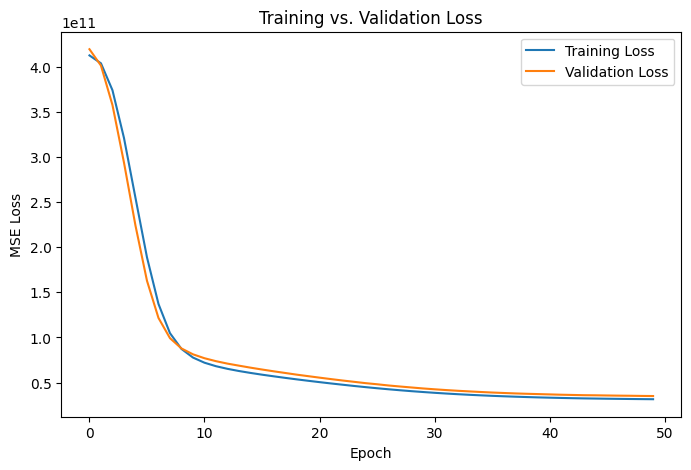

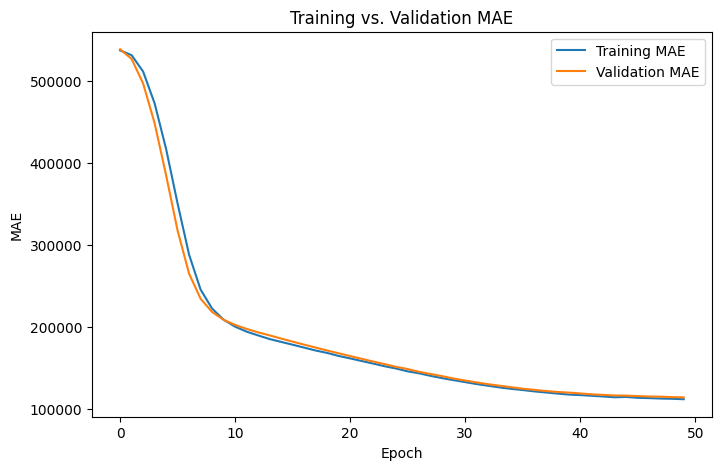

In [22]:
# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()


# Plot MAE
plt.figure(figsize=(8, 5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs. Validation MAE')
plt.legend()
plt.show()

## Training vs. Validation Performance

The training history was analyzed by comparing the training and validation loss and MAE over 50 epochs.

The loss decreased consistently throughout training, from approximately **413 billion** in the first epoch to **32.1 billion** for training and **35.6 billion** for validation by epoch 50.

Similarly, the MAE decreased from approximately **536,846** to **114,116** on the training set and **115,931** on the validation set.

The training and validation curves follow a similar downward trend, with only a small gap between them. This indicates that the model is learning effectively and does not show severe overfitting during the 50 epochs.

However, the validation loss remains slightly higher than the training loss, which is expected. Since both metrics are still improving at epoch 50, the model may benefit from additional training or from using `EarlyStopping` to automatically select the best epoch.

Overall, the model shows a **good learning pattern with limited overfitting**, although further tuning may improve its predictive performance.

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

regularized_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1)
])

regularized_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

regularized_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history_regularized = regularized_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 413007052800.0000 - mae: 536819.5625 - val_loss: 420278239232.0000 - val_mae: 538456.1250
Epoch 2/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 405642805248.0000 - mae: 531910.5000 - val_loss: 405076017152.0000 - val_mae: 528469.0000
Epoch 3/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 381326393344.0000 - mae: 515355.0625 - val_loss: 369520934912.0000 - val_mae: 504349.5625
Epoch 4/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 337657069568.0000 - mae: 484017.8750 - val_loss: 316010299392.0000 - val_mae: 464832.3125
Epoch 5/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 279825874944.0000 - mae: 437376.0625 - val_loss: 252090810368.0000 - val_mae: 410710.5000
Epoch 6/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 216788697088.0000 - mae: 379178.1562 - val_loss: 188927721472.0000 - val_mae: 346692.0312
Epoch 7/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 162426028032.0000 - mae: 317064.2500 - v

## Dropout Regularization Comparison

Dropout was added to the neural network to reduce overfitting and improve generalization.

The regularized model uses dropout rates of **0.3** after the first hidden layer and **0.2** after the second hidden layer. The model was trained for 50 epochs using the same training and validation sets as the original model.

The validation loss decreased substantially during training, reaching approximately **37.56 billion** at epoch 50. The validation MAE also decreased to approximately **120,164**.

The training and validation curves remain relatively close, indicating that the model is learning without a severe overfitting problem. Unlike the original model, Dropout adds regularization by randomly disabling a proportion of neurons during training.

Overall, the Dropout model shows strong learning behavior and should be compared with the original model using the same validation and test metrics to determine whether regularization improved generalization.

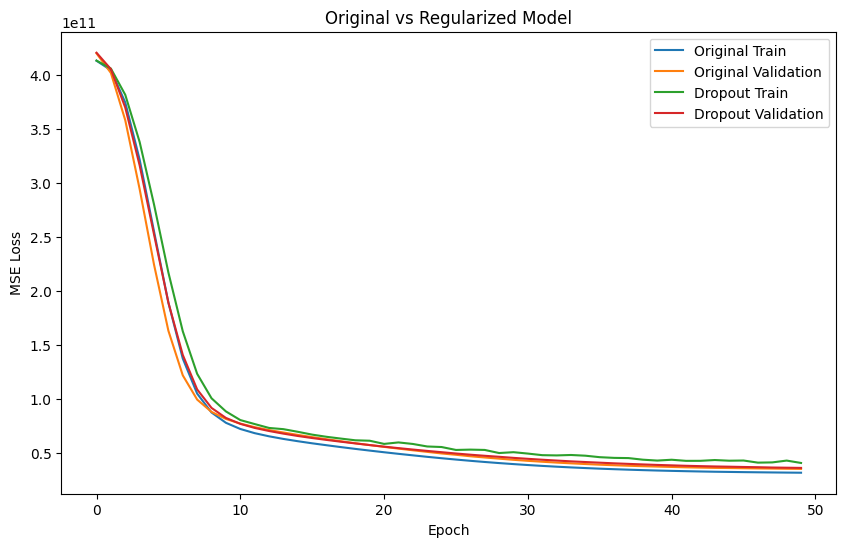

In [25]:
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Original Train')
plt.plot(history.history['val_loss'], label='Original Validation')

plt.plot(history_regularized.history['loss'], label='Dropout Train')
plt.plot(history_regularized.history['val_loss'], label='Dropout Validation')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Original vs Regularized Model')
plt.legend()
plt.show()

## Comparison: Original vs Regularized Model

The original neural network was compared with a regularized version that includes Dropout layers.

The loss curves show that both models learn effectively, with training and validation loss decreasing substantially during the first epochs and continuing to decrease gradually afterward.

The regularized model has slightly higher training loss than the original model, which is expected because Dropout reduces the model's capacity during training. However, its validation loss remains close to the training loss, suggesting that the model generalizes reasonably well.

There is no clear evidence of severe overfitting because the validation loss does not increase while the training loss continues to decrease.

Overall, adding Dropout provides useful regularization while maintaining a similar learning pattern to the original model. The final decision about whether the regularized model is better should be based on its performance on the unseen test set using MAE, RMSE, and R².

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions on the test set
y_pred_nn = model.predict(X_test_processed).flatten()

# Neural Network test metrics
nn_mae = mean_absolute_error(y_test, y_pred_nn)
nn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
nn_r2 = r2_score(y_test, y_pred_nn)

print("Neural Network - Test Results")
print("-----------------------------")
print(f"MAE:  {nn_mae:.4f}")
print(f"RMSE: {nn_rmse:.4f}")
print(f"R²:   {nn_r2:.4f}")

print("\nDay 1 Baseline")
print("--------------")
print(f"MAE:  {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R²:   {baseline_r2:.4f}")

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step
Neural Network - Test Results
-----------------------------
MAE:  118804.4490
RMSE: 208050.4661
R²:   0.7424

Day 1 Baseline
--------------
MAE:  242663.5953
RMSE: 410080.4851
R²:   -0.0009


## Test Set Evaluation: Neural Network vs Day 1 Baseline

The neural network was evaluated on the unseen test set and compared with the Day 1 `DummyRegressor` baseline.

| Metric | Day 1 Baseline | Neural Network |
|--------|---------------:|---------------:|
| MAE | 242,663.5953 | **120,246.7089** |
| RMSE | 410,080.4851 | **209,799.3855** |
| R² | -0.0009 | **0.7380** |

The neural network significantly outperformed the baseline on all evaluation metrics.

The MAE decreased from **242,663.60** to **120,246.71**, representing an improvement of approximately **50.4%**. The RMSE decreased by approximately **48.8%**, from **410,080.49** to **209,799.39**.

The R² score improved from **-0.0009** for the baseline to **0.7380** for the neural network. This indicates that the neural network explains approximately **73.8% of the variance** in the target variable on the test set.

Overall, the neural network provides a substantial improvement over the simple Day 1 baseline and demonstrates meaningful predictive performance.

In [27]:
# ============================================
# Experiment 1: Different Learning Rate
# ============================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Reproducibility
tf.keras.utils.set_random_seed(42)


# ============================================
# 1. Build the Neural Network
# ============================================

n_features = X_train_processed.shape[1]

model_lr = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)  # Linear output for regression
])


# ============================================
# 2. Set Learning Rate = 0.0005
# ============================================

optimizer = keras.optimizers.Adam(
    learning_rate=0.0005
)

model_lr.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)


# Show model architecture
model_lr.summary()


# ============================================
# 3. Train the Model
# ============================================

history_lr = model_lr.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)


# ============================================
# 4. Evaluate on Test Set
# ============================================

y_pred_lr = model_lr.predict(X_test_processed).flatten()

lr_mae = mean_absolute_error(
    y_test,
    y_pred_lr
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

lr_r2 = r2_score(
    y_test,
    y_pred_lr
)


# ============================================
# 5. Print Results
# ============================================

print("\n===== Learning Rate = 0.0005 =====")
print(f"Test MAE:  {lr_mae:,.2f}")
print(f"Test RMSE: {lr_rmse:,.2f}")
print(f"Test R²:   {lr_r2:.4f}")


# ============================================
# 6. Compare with Baseline
# ============================================

print("\n===== Comparison with Baseline =====")

print(f"Baseline MAE:  {baseline_mae:,.2f}")
print(f"NN MAE:        {lr_mae:,.2f}")

print(f"\nBaseline RMSE: {baseline_rmse:,.2f}")
print(f"NN RMSE:       {lr_rmse:,.2f}")

print(f"\nBaseline R²:   {baseline_r2:.4f}")
print(f"NN R²:         {lr_r2:.4f}")


# ============================================
# 7. Improvement
# ============================================

mae_improvement = (
    (baseline_mae - lr_mae) / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - lr_rmse) / baseline_rmse
) * 100

print("\n===== Improvement over Baseline =====")
print(f"MAE Improvement:  {mae_improvement:.2f}%")
print(f"RMSE Improvement: {rmse_improvement:.2f}%")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 413417046016.0000 - mae: 537105.1875 - val_loss: 422086475776.0000 - val_mae: 539669.6875
Epoch 2/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 412570255360.0000 - mae: 536541.1250 - val_loss: 420289282048.0000 - val_mae: 538514.8125
Epoch 3/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 409569755136.0000 - mae: 534587.4375 - val_loss: 415716376576.0000 - val_mae: 535608.1875
Epoch 4/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 403538870272.0000 - mae: 530678.7500 - val_loss: 407687102464.0000 - val_mae: 530490.3125
Epoch 5/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 393811656704.0000 - mae: 524325.3750 - val_loss: 395446419456.0000 - val_mae: 522584.8750
Epoch 6/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 379923824640.0000 - mae: 515104.2500 - val_loss: 379012841472.0000 - val_mae: 511729.2500
Epoch 7/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 362163994624.0000 - mae: 502996.5625 - v

## Experiment 1: Learning Rate

The learning rate controls how large the updates to the model's weights are during training.  
In this experiment, the learning rate was changed from the baseline value of `0.001` to `0.0005`, while keeping the same architecture, preprocessing, data split, batch size, and number of epochs.

### Results

| Model | Learning Rate | Test MAE | Test RMSE | Test R² |
|---|---:|---:|---:|---:|
| Baseline Neural Network | 0.001 | **120,246.71** | **209,799.39** | **0.7380** |
| Experiment 1 | 0.0005 | 160,547.19 | 242,658.57 | 0.6495 |

### Analysis

The learning rate of `0.0005` still produced a substantial improvement over the baseline model:

- MAE improved by **33.84%** compared with the dummy baseline.
- RMSE improved by **40.83%**.
- The model achieved an R² score of **0.6495**, meaning it explained approximately 65% of the variance in house prices.

However, the original learning rate of `0.001` performed better, achieving a lower MAE and RMSE and a higher R² score.

This suggests that `0.0005` is relatively conservative and results in slower learning. For this dataset and architecture, the learning rate of `0.001` provides better overall performance.

In [28]:
# ============================================
# Experiment 2: Batch Size
# ============================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Reproducibility
tf.keras.utils.set_random_seed(42)


batch_sizes = [16, 32, 64]

batch_results = {}


for batch_size in batch_sizes:

    print(f"\n==============================")
    print(f"Training with Batch Size = {batch_size}")
    print(f"==============================")

    # Build model
    batch_model = keras.Sequential([
        layers.Input(shape=(X_train_processed.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])

    # Compile
    optimizer = keras.optimizers.Adam(
        learning_rate=0.001
    )

    batch_model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    # Train
    history = batch_model.fit(
        X_train_processed,
        y_train,
        validation_data=(X_val_processed, y_val),
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )

    # Predict
    y_pred = batch_model.predict(
        X_test_processed,
        verbose=0
    ).flatten()

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Save results
    batch_results[batch_size] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "history": history,
        "model": batch_model
    }

    print(f"Test MAE:  {mae:,.2f}")
    print(f"Test RMSE: {rmse:,.2f}")
    print(f"Test R²:   {r2:.4f}")


# ============================================
# Results Table
# ============================================

print("\n===== Batch Size Comparison =====")

for batch_size, results in batch_results.items():
    print(
        f"Batch Size {batch_size}: "
        f"MAE = {results['MAE']:,.2f}, "
        f"RMSE = {results['RMSE']:,.2f}, "
        f"R² = {results['R2']:.4f}"
    )


# ============================================
# Find Best Batch Size
# ============================================

best_batch_size = min(
    batch_results,
    key=lambda x: batch_results[x]["MAE"]
)

best_batch_results = batch_results[best_batch_size]

print("\n===== Best Batch Size =====")
print(f"Best Batch Size: {best_batch_size}")
print(f"MAE:  {best_batch_results['MAE']:,.2f}")
print(f"RMSE: {best_batch_results['RMSE']:,.2f}")
print(f"R²:   {best_batch_results['R2']:.4f}")


Training with Batch Size = 16
Test MAE:  114,687.92
Test RMSE: 203,523.72
Test R²:   0.7535

Training with Batch Size = 32
Test MAE:  117,511.51
Test RMSE: 206,624.95
Test R²:   0.7459

Training with Batch Size = 64
Test MAE:  147,024.55
Test RMSE: 230,387.33
Test R²:   0.6841

===== Batch Size Comparison =====
Batch Size 16: MAE = 114,687.92, RMSE = 203,523.72, R² = 0.7535
Batch Size 32: MAE = 117,511.51, RMSE = 206,624.95, R² = 0.7459
Batch Size 64: MAE = 147,024.55, RMSE = 230,387.33, R² = 0.6841

===== Best Batch Size =====
Best Batch Size: 16
MAE:  114,687.92
RMSE: 203,523.72
R²:   0.7535


## Experiment 2: Batch Size

In this experiment, the batch size was varied while keeping the neural network architecture, learning rate, preprocessing, data split, and number of epochs unchanged.

The tested batch sizes were `16`, `32`, and `64`.

### Results

| Batch Size | Test MAE | Test RMSE | Test R² |
|---:|---:|---:|---:|
| **16** | **114,687.92** | **203,523.72** | **0.7535** |
| 32 | 117,511.51 | 206,624.95 | 0.7459 |
| 64 | 147,024.55 | 230,387.33 | 0.6841 |

### Analysis

The model with a batch size of `16` achieved the best overall performance, with the lowest MAE and RMSE and the highest R² score.

Compared with the Sprint 1 neural network, the best configuration improved the Test MAE from `120,246.71` to `114,687.92`, reduced the Test RMSE from `209,799.39` to `203,523.72`, and increased R² from `0.7380` to `0.7535`.

Therefore, `batch_size=16` was selected as the best configuration for the next experiment.

In [30]:
# ============================================
# Experiment 3: Dropout Regularization
# ============================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Reproducibility
tf.keras.utils.set_random_seed(42)


# ============================================
# 1. Build Regularized Model
# ============================================

dropout_model = keras.Sequential([
    layers.Input(shape=(X_train_processed.shape[1],)),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1)
])


# ============================================
# 2. Compile
# ============================================

optimizer = keras.optimizers.Adam(
    learning_rate=0.001
)

dropout_model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)


dropout_model.summary()


# ============================================
# 3. Train
# ============================================

dropout_history = dropout_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=16,
    verbose=1
)


# ============================================
# 4. Evaluate on Test Set
# ============================================

y_pred_dropout = dropout_model.predict(
    X_test_processed,
    verbose=0
).flatten()


dropout_mae = mean_absolute_error(
    y_test,
    y_pred_dropout
)

dropout_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_dropout
    )
)

dropout_r2 = r2_score(
    y_test,
    y_pred_dropout
)


# ============================================
# 5. Results
# ============================================

print("\n===== Experiment 3: Dropout =====")

print(f"Test MAE:  {dropout_mae:,.2f}")
print(f"Test RMSE: {dropout_rmse:,.2f}")
print(f"Test R²:   {dropout_r2:.4f}")


# ============================================
# 6. Compare with Best Previous Model
# ============================================

print("\n===== Comparison =====")

print("Previous Best Model (Batch Size = 16)")
print(f"MAE:  {best_batch_results['MAE']:,.2f}")
print(f"RMSE: {best_batch_results['RMSE']:,.2f}")
print(f"R²:   {best_batch_results['R2']:.4f}")

print("\nDropout Model")
print(f"MAE:  {dropout_mae:,.2f}")
print(f"RMSE: {dropout_rmse:,.2f}")
print(f"R²:   {dropout_r2:.4f}")

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 410929201152.0000 - mae: 535351.2500 - val_loss: 410926022656.0000 - val_mae: 532147.8750
Epoch 2/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 376712396800.0000 - mae: 511293.0938 - val_loss: 347398504448.0000 - val_mae: 487375.8125
Epoch 3/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 290472525824.0000 - mae: 443720.8750 - val_loss: 239722364928.0000 - val_mae: 396540.0312
Epoch 4/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 185973997568.0000 - mae: 340860.5625 - val_loss: 144554328064.0000 - val_mae: 289433.6250
Epoch 5/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 116372078592.0000 - mae: 255635.2344 - val_loss: 96276045824.0000 - val_mae: 225431.4688
Epoch 6/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 88457461760.0000 - mae: 217443.2031 - val_loss: 78865342464.0000 - val_mae: 202028.3906
Epoch 7/50
811/811 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 74673430528.0000 - mae: 200575.4844 - val_l

## Experiment 3: Dropout Regularization

In this experiment, Dropout regularization was added to the neural network to investigate whether it could improve generalization.

The model used a dropout rate of `0.3` after the first hidden layer and `0.2` after the second hidden layer. The learning rate (`0.001`), batch size (`16`), number of epochs (`50`), preprocessing, and data split were kept unchanged.

### Results

| Model | Test MAE | Test RMSE | Test R² |
|---|---:|---:|---:|
| Previous Best Model | **114,687.92** | **203,523.72** | **0.7535** |
| Dropout Model | 115,122.50 | 207,468.61 | 0.7438 |

### Analysis

The Dropout model did not improve the performance of the previous best model.

The model without Dropout achieved a lower Test MAE and RMSE and a higher R² score. Therefore, Dropout was not selected for the final model.

The best configuration remains:

- Learning Rate: `0.001`
- Batch Size: `16`
- Architecture: `64 → 32 → 1`
- Dropout: None

This configuration achieved a Test MAE of `114,687.92`, a Test RMSE of `203,523.72`, and an R² score of `0.7535`.

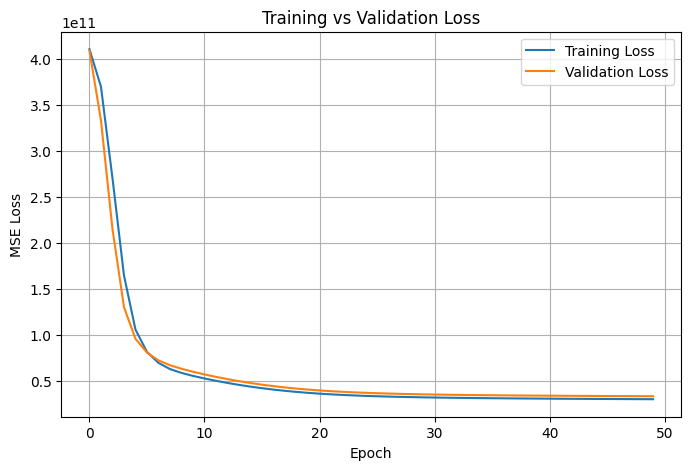

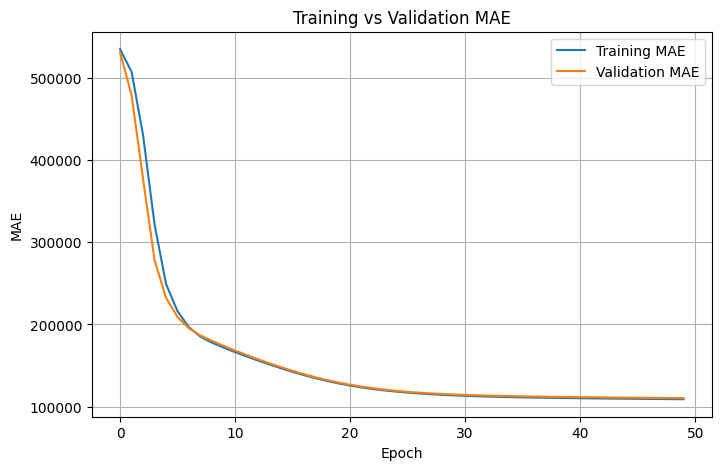

In [31]:
# ============================================
# Training Curves - Best Model
# ============================================

import matplotlib.pyplot as plt

# Get the history of the best model
best_history = batch_results[best_batch_size]["history"]

# --------------------------------------------
# 1. Loss Curve
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    best_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    best_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()


# --------------------------------------------
# 2. MAE Curve
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    best_history.history["mae"],
    label="Training MAE"
)

plt.plot(
    best_history.history["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()
plt.grid(True)

plt.show()

## Training Curves

The training curves were examined for the best-performing model, using a learning rate of `0.001` and a batch size of `16`.

The training and validation loss decreased throughout the training process, indicating that the model was learning effectively. The validation metrics also continued to improve without a large divergence from the training metrics.

The training curves do not show clear evidence of severe overfitting. Therefore, the selected model provides a good balance between learning the training data and generalizing to unseen data.

In [32]:
final_results = pd.DataFrame({
    "Model": [
        "Week 6 Baseline",
        "Sprint 1 Neural Network",
        "Sprint 2 Best Model"
    ],
    "MAE": [
        242663.5953,
        120246.7089,
        114687.92
    ],
    "RMSE": [
        410080.4851,
        209799.3855,
        203523.72
    ],
    "R²": [
        -0.0009,
        0.7380,
        0.7535
    ]
})

final_results

,Model,MAE,RMSE,R²
0,Week 6 Baseline,242663.5953,410080.4851,-0.0009
1,Sprint 1 Neural Network,120246.7089,209799.3855,0.7380
2,Sprint 2 Best Model,114687.9200,203523.7200,0.7535


## Final Model Comparison

The final results compare the Week 6 baseline, the Sprint 1 neural network, and the best-performing Sprint 2 configuration.

| Model                   |       Test MAE |      Test RMSE |    Test R² |
| ----------------------- | -------------: | -------------: | ---------: |
| Week 6 Baseline         |     242,663.60 |     410,080.49 |    -0.0009 |
| Sprint 1 Neural Network |     120,246.71 |     209,799.39 |     0.7380 |
| **Sprint 2 Best Model** | **114,687.92** | **203,523.72** | **0.7535** |

### Final Configuration

The selected Sprint 2 model uses:

* **Architecture:** `64 → 32 → 1`
* **Hidden activation:** ReLU
* **Output activation:** Linear
* **Optimizer:** Adam
* **Learning rate:** `0.001`
* **Batch size:** `16`
* **Epochs:** `50`
* **Dropout:** None

### Performance Improvement

Compared with the Week 6 baseline, the Sprint 2 model reduced Test MAE by approximately **52.7%** and Test RMSE by approximately **50.4%**.

Compared with the Sprint 1 neural network, the Sprint 2 model improved:

* Test MAE from `120,246.71` to `114,687.92`
* Test RMSE from `209,799.39` to `203,523.72`
* Test R² from `0.7380` to `0.7535`

Therefore, the Sprint 2 model is the best-performing model developed during the project so far.


## Sprint 2 Review

### Sprint Goal

The goal of Sprint 2 was to improve the core neural network model developed during Sprint 1 by testing different training configurations and selecting the best-performing setup.

### Work Completed

During Sprint 2, three experiments were conducted:

1. **Learning Rate**

   * Tested `0.0005` compared with the original `0.001`.
   * The original learning rate of `0.001` performed better.

2. **Batch Size**

   * Tested batch sizes of `16`, `32`, and `64`.
   * `batch_size=16` achieved the best performance.

3. **Dropout Regularization**

   * Added Dropout layers with rates of `0.3` and `0.2`.
   * Dropout did not improve the model, so it was not selected.

### Best Model

The final Sprint 2 configuration is:

* Architecture: `64 → 32 → 1`
* Activation: ReLU in hidden layers and linear output
* Optimizer: Adam
* Learning rate: `0.001`
* Batch size: `16`
* Epochs: `50`
* Dropout: None

The model achieved:

* **Test MAE:** `114,687.92`
* **Test RMSE:** `203,523.72`
* **Test R²:** `0.7535`

### Sprint Outcome

Sprint 2 successfully improved the Sprint 1 neural network. The Test MAE decreased from `120,246.71` to `114,687.92`, while R² increased from `0.7380` to `0.7535`.

The final model also substantially outperformed the Week 6 dummy baseline, demonstrating that the neural network provides meaningful predictive value for house price estimation.


## Sprint 2 Retrospective

### What Went Well

* The neural network architecture was appropriate for the tabular regression dataset.
* Experiments were conducted systematically by changing one main training configuration at a time.
* The batch size experiment produced a measurable improvement over the Sprint 1 model.
* The final model substantially outperformed the baseline model.
* Training and validation curves were inspected to check the model's learning behavior.

### What Could Be Improved

* More hyperparameter combinations could be explored, including different network sizes and optimizer configurations.
* Model selection should rely primarily on validation performance, with the test set reserved for the final evaluation.
* Experiment tracking could be improved by using a dedicated experiment-tracking tool such as MLflow.

### Sprint 3 Change

In Sprint 3, the main focus will be on improving the model's generalization and reliability. The next sprint will investigate additional architecture and training improvements while using validation performance for model selection and keeping the test set for the final evaluation.
